# Case D (AIOps KPI) - Tier 2 Baseline: LSTM Autoencoder (Event-Level Evaluation)


## Notebook summary

**Objective:**  
Implement the Tier 2 deep baseline (LSTM Autoencoder) for the AIOps KPI case study using the existing event-level evaluation harness established in `03_baselines_aiops_kpi_event`.

**Design constraints (locked):**  
- Validation-only threshold selection using event-F1; test results are reported without leakage.
- Event-level metrics are the headline evaluation; point-wise metrics (including AUROC and PR-AUC) are supporting diagnostics.
- Identical split usage to Tier 0–1 baselines (no re-splitting).
- Overwrite-only run folders keyed by performance-only `run_key`, with UPSERT logging into the performance-only master results table.
- Plots are displayed inline and saved into each run folder.

**What changes vs Tier 0–1:**  
Only anomaly score generation changes: the LSTM AE uses reconstruction error at the window end time. Thresholding, evaluation, plotting, and results logging remain identical.

**Primary outputs produced in this notebook:**  
- A window-length sensitivity table over candidate `L` values (validation event-F1 + runtime).
- One canonical Tier 2 run folder at the selected `L`, containing config, threshold, predictions, metrics, and figures.
- Updated performance-only master results (UPSERT by `run_key`).


## Imports, paths, and global configuration


In [2]:
from pathlib import Path
import sys

# --- Portable paths (paste near top of every case notebook) ---
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent  # assumes notebook is in <project>/notebooks
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CASE_STUDY = "aiops_kpi"          # change per notebook: ambient, nyc_taxi, cpu_utilisation, aiops_kpi
EXPERIMENT = "lstm_ae_event"    # change per notebook: baselines_event, lstm_ae_event, diffusion_event, etc.

RUNS_ROOT = PROJECT_ROOT / "results" / CASE_STUDY / EXPERIMENT / "runs"
ALL_RESULTS_PATH = PROJECT_ROOT / "results" / "all_results.csv"  # shared across cases


print("PROJECT_ROOT:", PROJECT_ROOT)
print("CURRENT EXPERIMENTS:", EXPERIMENT)

PROJECT_ROOT: /Users/nandipha/Desktop/masters
CURRENT EXPERIMENTS: lstm_ae_event


In [3]:
# from saved experiment utilities
from src.event_harness import REQUIRED_COLUMNS, PERF_COLUMNS

from src.event_harness import (
    load_split_csv, basic_checks,
    select_threshold_event_f1, evaluate_at_threshold,
    plot_score_timeline,
    make_run_key, run_dir_from_key, make_run_id_timestamp,
    save_json, save_df, load_all_results_or_empty,
    normalise_perf_row, upsert_all_results_row,
    auto_notes,
)
print("OK: Event harness imported")


OK: Event harness imported


## Step 1 - Load canonical split CSVs and run integrity checks


**Purpose:**  
Load the canonical AIOps KPI split CSVs used by Tier 0–1 baselines and confirm that the required columns and time ordering are present before any modelling is performed.

**Inputs:**  
- `aiops_kpi_train.csv`  
- `aiops_kpi_validation.csv`  
- `aiops_kpi_test.csv`  
from the processed dataset directory.

**Outputs (shown in-notebook):**  
- A split integrity summary table (row counts, time span, anomaly counts/proportions).
- A missing-value table for core columns (expected to be empty).

**Anti-leakage note:**  
This step performs loading and integrity checks only. No threshold selection or tuning is performed here.




In [4]:
# Step 1 - Load canonical splits (reuse baseline utilities: load_split_csv + basic_checks)

from pathlib import Path
import pandas as pd

# Canonical processed split paths (Case D: AIOps KPI)
AIOPS_PROCESSED_DIR = Path("/Users/nandipha/Desktop/masters/data/processed/aiops_kpi")

TRAIN_PATH = AIOPS_PROCESSED_DIR / "aiops_kpi_train.csv"
VAL_PATH   = AIOPS_PROCESSED_DIR / "aiops_kpi_validation.csv"
TEST_PATH  = AIOPS_PROCESSED_DIR / "aiops_kpi_test.csv"

# Load using the existing baseline loader (ensures consistent parsing + sorting)
train_df = load_split_csv(TRAIN_PATH)
val_df   = load_split_csv(VAL_PATH)
test_df  = load_split_csv(TEST_PATH)

# Run existing baseline integrity checks
train_summary, train_missing = basic_checks(train_df, "train")
val_summary,   val_missing   = basic_checks(val_df, "validation")
test_summary,  test_missing  = basic_checks(test_df, "test")

# Display split summaries as a single table
split_summary = pd.concat([train_summary, val_summary, test_summary], ignore_index=True)
display(split_summary)

# Display missing-value issues (if any) for core columns
missing_summary = (
    pd.concat(
        [
            train_missing.assign(split="train"),
            val_missing.assign(split="validation"),
            test_missing.assign(split="test"),
        ],
        ignore_index=True,
    )
    .query("missing_count > 0")
)

display(missing_summary if len(missing_summary) > 0 else "No missing values in core columns.")


,split,rows,anomaly_points,anomaly_rate,time_sorted,case_study_values
0,train,63999,563,0.008797,True,aiops_kpi
1,validation,17268,97,0.005617,True,aiops_kpi
2,test,47768,7006,0.146667,True,aiops_kpi


'No missing values in core columns.'

### Step 1 - Interpretation: Split integrity summary (AIOps KPI)

The canonical processed splits were loaded successfully and passed the core integrity checks.

**Observed split composition and anomaly density**
- **Train:** 63,999 rows with **563 anomaly points** (anomaly rate ≈ **0.0088**).
- **Validation:** 17,268 rows with **97 anomaly points** (anomaly rate ≈ **0.0056**).
- **Test:** 47,768 rows with **7,006 anomaly points** (anomaly rate ≈ **0.1467**).

**Ordering and schema checks**
- `time_sorted = True` for all splits, confirming chronological ordering is consistent.
- `case_study_values = aiops_kpi` across all splits, confirming case-study consistency.
- No missing values were detected in the required core columns.

**Interpretive note for downstream steps (non-decisional)**
- The **test split has a substantially higher anomaly density** than train/validation. This supports treating Case D as a high-pressure incident regime and reinforces the importance of:
  - validation-only threshold selection (to avoid leakage),
  - event-level metrics as the primary reporting signal,
  - drift-aware interpretation when comparing validation vs test performance later.


## Step 2 - Define window-length candidates and the sensitivity plan (Tier 2: LSTM AE)


**Purpose:**  
Define the candidate sliding window lengths (`L`) to be tested for the LSTM Autoencoder and formalise the sensitivity plan used to select a single window length for the canonical Tier 2 run.

**Inputs:**  
- Loaded split DataFrames: `train_df`, `val_df`, `test_df` (from Step 1).
- Case D sampling context (1-minute cadence with occasional gaps handled via contiguity enforcement in later steps).

**Outputs (shown in-notebook):**  
- A table listing the candidate `L` values (in minutes) and an interpretation of their temporal coverage.
- An empty sensitivity-results table scaffold showing the columns that will be populated per candidate.

**Anti-leakage note:**  
This step defines candidates and reporting structure only. No model fitting, threshold selection, or test-based selection occurs here.

**Saved artefacts:**  
None (the sensitivity table is saved only after it contains results).


In [10]:
# Step 2 — Candidate window lengths (L) + sensitivity plan scaffolding

import pandas as pd

# Candidate window lengths for Case D (1-minute sampling), as per charter defaults.
# These represent 1 hour, 2 hours, 6 hours, and 1 day of context.
L_CANDIDATES = [60, 120, 360, 1440]


# Display candidate coverage in a reader-friendly table
l_candidates_table = pd.DataFrame(
    {
        "L_minutes": L_CANDIDATES,
        "L_hours": [round(L / 60, 2) for L in L_CANDIDATES],
        "Interpretation": [
            "Short context (≈1 hour); sensitive to sharp deviations",
            "Moderate short context (≈2 hours); balances responsiveness and stability",
            "Medium context (≈6 hours); captures longer incident build-up patterns",
            "Long context (≈24 hours); captures daily structure but higher compute cost",
        ],
    }
)

pd.set_option("display.max_colwidth", None)   # show full text in cells
pd.set_option("display.max_columns", None)    # show all columns
pd.set_option("display.width", 0)     
display(l_candidates_table)

# Sensitivity table scaffold (populated in later steps after each candidate run finishes)
# Event-level validation metrics remain the primary selection signal.
lstm_ae_sensitivity = pd.DataFrame(
    columns=[
        "L_minutes",
        "val_event_precision",
        "val_event_recall",
        "val_event_f1",
        "val_event_delay_median_minutes",
        "test_event_precision",
        "test_event_recall",
        "test_event_f1",
        "test_event_delay_median_minutes",
        "test_pr_auc",
        "test_auroc",
        "train_seconds",
        "score_seconds",
        "threshold_strategy",
        "threshold_value",
        "run_key",
        "run_id",
        "notes",
    ]
)

display(lstm_ae_sensitivity)


,L_minutes,L_hours,Interpretation
0,60,1.0,Short context (≈1 hour); sensitive to sharp deviations
1,120,2.0,Moderate short context (≈2 hours); balances responsiveness and stability
2,360,6.0,Medium context (≈6 hours); captures longer incident build-up patterns
3,1440,24.0,Long context (≈24 hours); captures daily structure but higher compute cost


,L_minutes,val_event_precision,val_event_recall,val_event_f1,val_event_delay_median_minutes,test_event_precision,test_event_recall,test_event_f1,test_event_delay_median_minutes,test_pr_auc,test_auroc,train_seconds,score_seconds,threshold_strategy,threshold_value,run_key,run_id,notes


### Step 2 - Interpretation: Candidate window lengths and sensitivity table scaffold

The candidate window lengths (`L`) for the Tier 2 LSTM Autoencoder sensitivity study were defined and displayed with their temporal coverage:

- **L = 60 minutes (1.0 hour):** short context; sensitive to sharp deviations.
- **L = 120 minutes (2.0 hours):** moderate short context; balances responsiveness and stability.
- **L = 360 minutes (6.0 hours):** medium context; captures longer incident build-up patterns.
- **L = 1440 minutes (24.0 hours):** long context; captures daily structure but incurs higher compute cost.

A Tier 2 sensitivity results table scaffold was also created to record, for each candidate `L`, the validation-selected threshold, event-level metrics (primary), supporting point-wise ranking metrics (AUROC, PR-AUC), runtime, and the run identifiers (`run_key`, `run_id`) required for reproducible run tracking.


## Step 3 - Implement contiguity-aware window validity for 1-minute series (Tier 2 specific)


**Purpose:**  
Define a contiguity rule that marks which window end times are valid for a 1-minute sampled series, so that LSTM windows do not cross gaps. This is required for Case D, which contains occasional missing minutes.

**Inputs:**  
- `df_split["time"]` (datetime, sorted).
- Window length `L` in minutes (number of points per window).

**Outputs (shown in-notebook):**  
- For each split and candidate `L`: the number of valid window ends and usable windows.
- A windowing summary table with drop rates.

**Anti-leakage note:**  
This step performs deterministic window eligibility filtering only. No thresholds are chosen and no model fitting is performed.

**Saved artefacts:**  
None (windows are constructed in memory only).


In [6]:
# Step 3 — Tier 2 specific contiguity mask for 1-minute sampling (define immediately above use)

import numpy as np
import pandas as pd

def valid_window_end_mask_1min(times: pd.Series, L: int) -> np.ndarray:
    """
    Return a boolean mask (len = n_rows) where True indicates that index i can be a valid
    window end for a length-L causal window under 1-minute sampling, i.e.:
      - i >= L-1
      - the last L timestamps are strictly 1-minute contiguous (no gaps)
    """
    t = pd.to_datetime(times).to_numpy()
    n = t.shape[0]
    if n == 0:
        return np.zeros(0, dtype=bool)

    # Differences in minutes between consecutive timestamps
    dt_min = (t[1:] - t[:-1]).astype("timedelta64[m]").astype(int)  # length n-1

    # True where consecutive step is exactly 1 minute
    is_step_ok = (dt_min == 1).astype(int)

    # For an end index i, the window [i-L+1 .. i] is contiguous iff
    # all (L-1) steps inside that window are 1-minute steps.
    # That corresponds to sum(is_step_ok[i-L+1 : i]) == (L-1).
    valid = np.zeros(n, dtype=bool)
    if L <= 1:
        # Degenerate: a "window" of length 1 is always contiguous
        valid[:] = True
        return valid

    # Prefix sums allow O(1) window step-sum queries
    csum = np.concatenate([[0], np.cumsum(is_step_ok)])  # length n
    for i in range(L - 1, n):
        step_sum = csum[i] - csum[i - (L - 1)]
        valid[i] = (step_sum == (L - 1))

    return valid


def build_contiguous_windows_1min(
    df_split: pd.DataFrame,
    L: int,
    value_col: str = "value_scaled",
) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Build sliding windows of length L from a 1-minute series, excluding windows that cross gaps.

    Returns
    -------
    X : np.ndarray
        Shape (n_windows, L, 1) for LSTM input.
    meta : pd.DataFrame
        One row per window with:
        - time_end: window end timestamp
        - is_anomaly_end: ground-truth label at window end (point label, used by harness)
    """
    df = df_split.sort_values("time").reset_index(drop=True)

    valid_end_mask = valid_window_end_mask_1min(df["time"], L=L)
    end_idx = np.where(valid_end_mask)[0]

    if len(end_idx) == 0:
        X = np.empty((0, L, 1), dtype=float)
        meta = pd.DataFrame(columns=["time_end", "is_anomaly_end"])
        return X, meta

    values = df[value_col].to_numpy(dtype=float)

    windows = []
    for i in end_idx:
        start = i - (L - 1)
        windows.append(values[start : i + 1])

    X = np.stack(windows, axis=0)[:, :, None]  # (n_windows, L, 1)

    meta = pd.DataFrame(
        {
            "time_end": df.loc[end_idx, "time"].to_numpy(),
            "is_anomaly_end": df.loc[end_idx, "is_anomaly"].astype(int).to_numpy(),
        }
    )
    return X, meta


# Build and summarise window availability for each candidate L
rows = []
window_store = {}  # keyed by (split_name, L)

for split_name, df_split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    n_rows = len(df_split)

    for L in L_CANDIDATES:
        X, meta = build_contiguous_windows_1min(df_split, L=L)
        window_store[(split_name, L)] = (X, meta)

        n_windows = X.shape[0]
        drop_rate = 1.0 - (n_windows / max(n_rows, 1))

        rows.append(
            {
                "split": split_name,
                "rows": n_rows,
                "L_minutes": L,
                "usable_windows": n_windows,
                "drop_rate": round(drop_rate, 4),
            }
        )

windowing_summary = pd.DataFrame(rows).sort_values(["split", "L_minutes"]).reset_index(drop=True)
display(windowing_summary)

# Preview window end timestamps for validation and test for the smallest candidate (sanity check)
L_preview = L_CANDIDATES[0]
_, meta_val_preview = window_store[("validation", L_preview)]
_, meta_test_preview = window_store[("test", L_preview)]

display(meta_val_preview.head(5))
display(meta_test_preview.head(5))


,split,rows,L_minutes,usable_windows,drop_rate
0,test,47768,60,47237,0.0111
1,test,47768,120,46697,0.0224
2,test,47768,360,44567,0.0670
3,test,47768,1440,37330,0.2185
4,train,63999,60,62518,0.0231
5,train,63999,120,61124,0.0449
6,train,63999,360,56643,0.1149
7,train,63999,1440,40535,0.3666
8,validation,17268,60,16914,0.0205
9,validation,17268,120,16554,0.0413


,time_end,is_anomaly_end
0,2017-06-16 00:59:00,0
1,2017-06-16 01:00:00,0
2,2017-06-16 01:01:00,0
3,2017-06-16 01:02:00,0
4,2017-06-16 01:03:00,0


,time_end,is_anomaly_end
0,2017-06-28 00:59:00,0
1,2017-06-28 01:00:00,0
2,2017-06-28 01:01:00,0
3,2017-06-28 01:02:00,0
4,2017-06-28 01:03:00,0


## Step 3 - Interpretation: Contiguity-aware window construction and usable window coverage

Contiguity-aware sliding windows were constructed successfully for each split and each candidate window length `L`, ensuring that no LSTM input window crosses a missing-minute gap. The resulting usable window counts and drop rates quantify the trade-off between longer temporal context and the increased likelihood of encountering gaps.

### Usable window coverage by split and window length
**Test (47,768 rows)**
- **L=60:** 47,237 usable windows (drop rate **0.0111**)
- **L=120:** 46,697 usable windows (drop rate **0.0224**)
- **L=360:** 44,567 usable windows (drop rate **0.0670**)
- **L=1440:** 37,330 usable windows (drop rate **0.2185**)

**Train (63,999 rows)**
- **L=60:** 62,518 usable windows (drop rate **0.0231**)
- **L=120:** 61,124 usable windows (drop rate **0.0449**)
- **L=360:** 56,643 usable windows (drop rate **0.1149**)
- **L=1440:** 40,535 usable windows (drop rate **0.3666**)

**Validation (17,268 rows)**
- **L=60:** 16,914 usable windows (drop rate **0.0205**)
- **L=120:** 16,554 usable windows (drop rate **0.0413**)
- **L=360:** 15,114 usable windows (drop rate **0.1247**)
- **L=1440:** 9,382 usable windows (drop rate **0.4567**)

### Practical implications for the sensitivity study
- Increasing `L` reduces usable windows across all splits because longer windows are more likely to span a gap.
- The reduction is most pronounced for **L=1440**, where nearly **46%** of validation window ends are excluded and roughly **37%** of training window ends are excluded. This implies a substantial reduction in effective training and calibration signal at the longest context length.
- Shorter contexts (**60–120 minutes**) retain most windows, preserving sample size while still providing temporal context suitable for short-range incident dynamics.

### Alignment check: window end timestamps
The `time_end` previews confirm that each constructed window is aligned to a valid window end timestamp (e.g., minute-level progression), with an `is_anomaly_end` label attached at the window end time. This preserves compatibility with the existing harness, which expects timestamp-indexed scores and supports event-level evaluation after thresholding.


## Step 4 - Define the LSTM Autoencoder model and training protocol (Tier 2)


**Purpose:**  
Define the LSTM Autoencoder architecture, training hyperparameters, and reproducibility controls that will be used consistently across the window-length sensitivity runs. This step establishes the model specification without yet executing the sensitivity loop.

**Inputs:**  
- Sequence windows constructed in Step 3 (to be used in later steps for training and scoring).
- Feasibility constraints from the Modelling and Evaluation Charter (limited compute; small, justified hyperparameter choices).

**Outputs (shown in-notebook):**  
- A configuration dictionary specifying the model architecture and training settings.
- A short statement of how reconstruction error will be converted into an anomaly score at the window end time (implemented in Step 5).

**Anti-leakage note:**  
This step defines a fixed training protocol only. Threshold selection and any model selection decisions are performed on validation only in later steps.

**Saved artefacts:**  
None in this step (the configuration is saved into each run folder as `config.json` during sensitivity runs).


In [7]:
# Step 4 - LSTM AE configuration (model + training protocol), reused across sensitivity runs

import numpy as np

# Reproducibility
SEED = 42

# LSTM AE design (kept lightweight for feasibility constraints)
lstm_ae_config = {
    "model_family": "lstm_autoencoder",
    "input_features": ["value_scaled"],      # single-channel sequence
    "reconstruction_loss": "mse",
    "seed": SEED,
    # Architecture (lightweight baseline; can be adjusted later if justified)
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    # Training protocol (kept modest; early stopping is recommended in implementation)
    "batch_size": 256,
    "learning_rate": 1e-3,
    "max_epochs": 20,
    "early_stopping": {
        "enabled": True,
        "patience": 3,
        "min_delta": 1e-4,
        "monitor": "val_loss",
    },
    # Scoring definition (implemented in Step 5/6)
    "anomaly_score_definition": "window_end_reconstruction_mse",
}

lstm_ae_config


{'model_family': 'lstm_autoencoder',
 'input_features': ['value_scaled'],
 'reconstruction_loss': 'mse',
 'seed': 42,
 'hidden_size': 32,
 'num_layers': 1,
 'dropout': 0.0,
 'batch_size': 256,
 'learning_rate': 0.001,
 'max_epochs': 20,
 'early_stopping': {'enabled': True,
  'patience': 3,
  'min_delta': 0.0001,
  'monitor': 'val_loss'},
 'anomaly_score_definition': 'window_end_reconstruction_mse'}

## Step 4 - Interpretation: LSTM AE configuration and the role of each element

This configuration defines a lightweight, reproducible LSTM Autoencoder baseline for Case D, designed to be feasible under constrained compute while remaining comparable across window-length sensitivity runs.

### Model identity and input design
- **`model_family: "lstm_autoencoder"`**  
  Declares the method class for reporting and run tracking. This supports clear comparisons against Tier 0–1 baselines and later diffusion models.

- **`input_features: ["value_scaled"]`**  
  Uses only the standardised signal as the sequence input. This keeps the baseline interpretable and avoids introducing additional feature engineering that could confound comparisons at this stage.

### Learning objective and reconstruction behaviour
- **`reconstruction_loss: "mse"`**  
  The model is trained to reconstruct its input windows; mean squared error penalises larger reconstruction mistakes more strongly than small ones. Under this design, windows that the model reconstructs poorly are expected to yield higher anomaly scores.

- **`anomaly_score_definition: "window_end_reconstruction_mse"`**  
  Specifies how reconstruction error becomes the anomaly score. The score is computed from reconstruction error and associated with the **window end time**, aligning with the existing harness (timestamp-indexed scores and event-level evaluation).

### Reproducibility controls
- **`seed: 42`**  
  Fixes random initialisation and training stochasticity (to the extent supported by the environment). This reduces run-to-run variability and improves auditability when comparing candidates.

### Architecture (capacity vs feasibility)
- **`hidden_size: 32`**  
  Sets the model’s representational capacity. A smaller hidden size reduces overfitting risk and runtime. This is appropriate as a Tier 2 baseline whose role is to provide a deep-learning reference point rather than maximise capacity.

- **`num_layers: 1`**  
  Uses a single LSTM layer to keep the baseline simple and stable. Deeper stacks increase capacity and compute cost and are better introduced only if needed and justified by sensitivity outcomes.

- **`dropout: 0.0`**  
  Disables dropout regularisation. This keeps training dynamics straightforward; regularisation can be introduced later only if overfitting is evident (e.g., validation reconstruction error diverges from training behaviour).

### Training protocol (efficiency and stability)
- **`batch_size: 256`**  
  Controls how many windows are processed per parameter update. Larger batches tend to be more compute-efficient and yield smoother training, but require more memory. This value is a practical balance for feasibility.

- **`learning_rate: 0.001`**  
  Controls step size in optimisation. This is a common stable default for Adam-style optimisation and supports consistent behaviour during sensitivity testing.

- **`max_epochs: 20`**  
  Places an upper bound on training time. The intent is to avoid excessive tuning and keep the Tier 2 baseline feasible while still allowing the model to converge.

### Early stopping (prevents unnecessary training and reduces overfit risk)
- **`early_stopping.enabled: True`**  
  Activates stopping when validation performance stops improving, reducing wasted compute and limiting overfitting.

- **`early_stopping.monitor: "val_loss"`**  
  Uses validation reconstruction loss as the stopping signal, aligning with the reconstruction objective.

- **`early_stopping.patience: 3`**  
  Allows a small number of non-improving epochs before stopping, preventing premature termination due to noise.

- **`early_stopping.min_delta: 0.0001`**  
  Defines what counts as a meaningful improvement. This avoids treating negligible fluctuations as progress.

### Summary (why this configuration is appropriate here)
Overall, the configuration defines a minimal, stable Tier 2 baseline: a single-channel LSTM Autoencoder trained under clear reproducibility and feasibility constraints. It creates reconstruction-error anomaly scores that integrate directly into the existing event-level thresholding and evaluation harness without altering the pipeline.


## Step 5 - Define the LSTM Autoencoder implementation and scoring functions


**Purpose:**  
Implement the LSTM Autoencoder (encoder–decoder) and define how reconstruction error is computed as an anomaly score. These functions are used consistently across all window-length sensitivity runs.

**Inputs:**  
- LSTM AE configuration from Step 4 (`lstm_ae_config`).
- Window tensors produced in Step 3 (used later when training and scoring).

**Outputs (shown in-notebook):**  
- Model class definition.
- Training function returning the fitted model and a compact training history table.
- Scoring function returning an anomaly score per window (aligned to the window end time via the metadata built in Step 3).

**Anti-leakage note:**  
This step defines reusable model code only. No threshold selection is performed here. When training occurs in later steps, model fitting uses training windows only, and early stopping uses validation windows only.

**Saved artefacts:**  
None in this step (artefacts are saved per run during the sensitivity loop).


In [8]:
# Step 5 - LSTM AE model + training + scoring (PyTorch implementation)

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def set_torch_seed(seed: int) -> None:
    """Set torch/random seeds for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


class LSTMAutoencoder(nn.Module):
    """
    Lightweight LSTM Autoencoder for 1D sequences.

    Input shape:  (batch, L, 1)
    Output shape: (batch, L, 1)
    """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.proj = nn.Linear(hidden_size, input_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encode sequence -> take latent states (all timesteps)
        z, (h_n, c_n) = self.encoder(x)  # z: (batch, L, hidden)
        # Decode: feed z into decoder (simple baseline)
        dec_out, _ = self.decoder(z)     # (batch, L, hidden)
        # Project back to input dimension
        x_hat = self.proj(dec_out)       # (batch, L, input_size)
        return x_hat


def train_lstm_ae(
    X_train: np.ndarray,
    X_val: np.ndarray,
    config: dict,
    device: str = "cpu",
) -> tuple[LSTMAutoencoder, pd.DataFrame]:
    """
    Train the LSTM AE on train windows only, using validation windows for early stopping.

    Returns
    -------
    model : trained model (best validation loss state)
    history_df : per-epoch loss history (train_loss, val_loss)
    """
    set_torch_seed(int(config["seed"]))

    model = LSTMAutoencoder(
        input_size=1,
        hidden_size=int(config["hidden_size"]),
        num_layers=int(config["num_layers"]),
        dropout=float(config["dropout"]),
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=float(config["learning_rate"]))

    # Data loaders
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32))

    train_loader = DataLoader(train_ds, batch_size=int(config["batch_size"]), shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=int(config["batch_size"]), shuffle=False, drop_last=False)

    # Early stopping settings
    es_cfg = config["early_stopping"]
    use_es = bool(es_cfg.get("enabled", True))
    patience = int(es_cfg.get("patience", 3))
    min_delta = float(es_cfg.get("min_delta", 1e-4))

    best_val = np.inf
    best_state = None
    bad_epochs = 0

    history = []

    for epoch in range(1, int(config["max_epochs"]) + 1):
        model.train()
        train_losses = []

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            xb_hat = model(xb)
            loss = criterion(xb_hat, xb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) else np.nan

        model.eval()
        val_losses = []
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                xb_hat = model(xb)
                loss = criterion(xb_hat, xb)
                val_losses.append(loss.item())

        val_loss = float(np.mean(val_losses)) if len(val_losses) else np.nan
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        # Early stopping check
        improved = (best_val - val_loss) > min_delta
        if improved:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if use_es and bad_epochs >= patience:
            break

    # Restore best model state
    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def score_lstm_ae_reconstruction_mse(
    model: LSTMAutoencoder,
    X: np.ndarray,
    device: str = "cpu",
    batch_size: int = 512,
) -> np.ndarray:
    """
    Compute anomaly scores as mean reconstruction MSE per window.
    Returns one score per window (aligned to window end time via meta table).
    """
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=batch_size, shuffle=False)

    scores = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            xb_hat = model(xb)
            # MSE over time and feature dims -> one score per window
            mse = torch.mean((xb_hat - xb) ** 2, dim=(1, 2))
            scores.append(mse.cpu().numpy())

    return np.concatenate(scores, axis=0) if len(scores) else np.array([], dtype=float)


# Minimal sanity: show the model class name (no training yet)
LSTMAutoencoder


__main__.LSTMAutoencoder

## Step 5 - Interpretation: LSTM Autoencoder class successfully defined

The LSTM Autoencoder model class has been defined in the notebook and is available in the current kernel session (confirmed by the class object representation).

This completes the model-definition portion of Tier 2 setup. The next steps can proceed to:
- training the model on contiguous training windows (per candidate window length `L`), and
- generating reconstruction-error anomaly scores aligned to each window end time for validation and test, which will then be passed to the existing event-level thresholding and evaluation harness.


## Step 6 - Micro-pilot: Train on a fixed subsample and score full validation/test (L = 60) (deterministic)


**Purpose:**  
Run a deterministic micro-pilot to validate the Tier 2 LSTM AE flow (window input → training → reconstruction-error scoring aligned to `time_end`) without the full CPU cost of training on all windows. Determinism is enforced by fixed random seeds and fixed subsample indices.

**Inputs:**  
- `window_store[("train", 60)]`, `window_store[("validation", 60)]`, `window_store[("test", 60)]` from Step 3.
- `lstm_ae_config` from Step 4 (seed-controlled).
- LSTM AE training and scoring functions from Step 5.

**Outputs (shown in-notebook):**  
- Training history (epoch, train_loss, val_loss).
- Runtime summary (micro-train seconds, scoring seconds).
- Validation alignment preview (`time_end`, `is_anomaly_end`, `anomaly_score`).

**Anti-leakage note:**  
Training uses training windows only. Validation windows are used only for monitoring and later threshold selection. Test data is scored only.

**Saved artefacts:**  
None (pilot is a correctness check, not a formal logged run).


In [11]:
# Step 6 — Deterministic micro-pilot (fixed seeds + fixed subsample indices)

import numpy as np
import pandas as pd
import time

# -----------------------------
# 0) Determinism controls
# -----------------------------
SEED = int(lstm_ae_config["seed"])
np.random.seed(SEED)  # defensive; training function also sets seeds internally

# -----------------------------
# 1) Select pilot window length
# -----------------------------
L_pilot = 60

# -----------------------------
# 2) Load windows + metadata
# -----------------------------
X_train, meta_train = window_store[("train", L_pilot)]
X_val,   meta_val   = window_store[("validation", L_pilot)]
X_test,  meta_test  = window_store[("test", L_pilot)]

# Sanity checks (shape + alignment)
assert X_train.ndim == 3 and X_train.shape[1] == L_pilot and X_train.shape[2] == 1
assert X_val.shape[1] == L_pilot and X_test.shape[1] == L_pilot
assert len(meta_val) == X_val.shape[0]
assert len(meta_test) == X_test.shape[0]

# -----------------------------
# 3) Deterministic subsampling
# -----------------------------
# Fixed RNG and fixed sizes (no replace). Re-running this cell should pick the same indices.
rng = np.random.default_rng(SEED)

n_train = min(6000, X_train.shape[0])
n_val   = min(2000, X_val.shape[0])

train_idx = rng.choice(X_train.shape[0], size=n_train, replace=False)
val_idx   = rng.choice(X_val.shape[0], size=n_val, replace=False)

# Sort indices so batch ordering is stable and easier to debug
train_idx = np.sort(train_idx)
val_idx   = np.sort(val_idx)

X_train_small = X_train[train_idx]
X_val_small   = X_val[val_idx]

# -----------------------------
# 4) Micro config (cap epochs)
# -----------------------------
micro_cfg = dict(lstm_ae_config)
micro_cfg["max_epochs"] = 5
micro_cfg["batch_size"] = int(lstm_ae_config["batch_size"])  # keep consistent

# -----------------------------
# 5) Train (micro-pilot)
# -----------------------------
t0 = time.time()
model, history_df = train_lstm_ae(X_train=X_train_small, X_val=X_val_small, config=micro_cfg, device="cpu")
micro_train_seconds = time.time() - t0

display(history_df)

# -----------------------------
# 6) Score full validation + test
# -----------------------------
t1 = time.time()
val_scores = score_lstm_ae_reconstruction_mse(model=model, X=X_val, device="cpu", batch_size=512)
test_scores = score_lstm_ae_reconstruction_mse(model=model, X=X_test, device="cpu", batch_size=512)
score_seconds = time.time() - t1

# -----------------------------
# 7) Print checks + preview alignment
# -----------------------------
print("SEED:", SEED)
print("Pilot L:", L_pilot)
print("Micro train windows:", X_train_small.shape[0], "| Micro validation windows:", X_val_small.shape[0])
print("Val windows:", X_val.shape[0], "| Test windows:", X_test.shape[0])
print("Val scores:", val_scores.shape, "| Test scores:", test_scores.shape)
print("Micro train seconds:", round(micro_train_seconds, 2))
print("Score seconds:", round(score_seconds, 2))

val_alignment_preview = meta_val.copy()
val_alignment_preview["anomaly_score"] = val_scores
display(val_alignment_preview.head(10))


,epoch,train_loss,val_loss
0,1,0.841459,0.735647
1,2,0.295541,0.403594
2,3,0.167446,0.357683
3,4,0.126160,0.319446
4,5,0.099684,0.288589


SEED: 42
Pilot L: 60
Micro train windows: 6000 | Micro validation windows: 2000
Val windows: 16914 | Test windows: 47237
Val scores: (16914,) | Test scores: (47237,)
Micro train seconds: 134.0
Score seconds: 59.15


,time_end,is_anomaly_end,anomaly_score
0,2017-06-16 00:59:00,0,0.016443
1,2017-06-16 01:00:00,0,0.016040
2,2017-06-16 01:01:00,0,0.015363
3,2017-06-16 01:02:00,0,0.014426
4,2017-06-16 01:03:00,0,0.013287
5,2017-06-16 01:04:00,0,0.012027
6,2017-06-16 01:05:00,0,0.013936
7,2017-06-16 01:06:00,0,0.013279
8,2017-06-16 01:07:00,0,0.015028
9,2017-06-16 01:08:00,0,0.014821


### Step 6 - Interpretation: Deterministic micro-pilot confirms stable Tier 2 training and score alignment (L = 60)

A deterministic micro-pilot was executed to validate the Tier 2 LSTM Autoencoder workflow under controlled sampling and fixed seeds. The run confirms that the implementation trains correctly, produces reconstruction-error anomaly scores at the expected scale, and aligns scores to the window end timestamps required by the existing evaluation harness.

### Determinism and pilot scope
- **Seed:** 42
- **Window length:** L = 60 (1-hour context)
- **Training sample:** 6,000 contiguous windows (subsampled deterministically)
- **Validation sample for monitoring:** 2,000 contiguous windows (subsampled deterministically)
- **Scoring:** full-window scoring on the complete validation and test window sets

### Training dynamics (micro-pilot)
Loss values decreased steadily across the 5-epoch cap, indicating stable optimisation and a functioning reconstruction objective:
- Train loss decreased from **0.8415 → 0.1000**
- Validation loss decreased from **0.7356 → 0.2886**

This behaviour is consistent with a model learning to reconstruct typical patterns in the input windows.

### Runtime feasibility (micro-pilot)
- **Micro training time:** 134.0 seconds
- **Full scoring time (validation + test):** 59.15 seconds

This supports the earlier observation that full training over all windows may be computationally expensive on CPU, while full scoring is comparatively feasible.

### Output integrity and harness compatibility
Shape checks confirm that scoring outputs match window metadata exactly:
- Validation windows: **16,914** and validation scores: **(16,914,)**
- Test windows: **47,237** and test scores: **(47,237,)**

The preview table confirms correct alignment:
- Each `time_end` has a corresponding `anomaly_score`
- `is_anomaly_end` is attached to the same window end time, enabling downstream thresholding and event evaluation without interface changes.

### Operational conclusion
The deterministic micro-pilot provides a clean correctness checkpoint: the Tier 2 LSTM AE pipeline produces valid, timestamp-aligned reconstruction-error anomaly scores suitable for the next steps (validation-only threshold selection and event-level evaluation) and for scaling into the formal sensitivity loop across all candidate window lengths.


## Step 7 - Define formal Tier 2 run identifiers (run_key + run_dir) for the sensitivity study


**Purpose:**  
Define the deterministic run identifiers used for formal Tier 2 sensitivity runs, ensuring that each candidate window length `L` maps to a stable `run_key` and a stable `run_dir`. This enables overwrite-only reruns (same `run_key`) and consistent UPSERT logging into the performance-only master results table.

**Inputs:**  
- Candidate window lengths: `L_CANDIDATES` (Step 2).
- Portable path variables already defined in the notebook (e.g., `CASE_STUDY`, `RUNS_ROOT`, `ALL_RESULTS_PATH`).
- Harness utilities (imported from `src.event_harness`):
  - `make_run_key(...)`
  - `run_dir_from_key(...)`

**Outputs (shown in-notebook):**  
- A run plan table listing, for each `L`:
  - `run_key` (performance-only identity)
  - `run_dir` (overwrite-only run folder path)
  - the key run descriptors used to construct the identifier

**Anti-leakage note:**  
This step defines identifiers only. No model training, threshold selection, test evaluation, or results logging is performed here.

**Saved artefacts:**  
None.


In [9]:
# Step 7 — Formal Tier 2 run plan (preview only; no logging)

import pandas as pd

# --- Tier 2 identifiers (match baseline conventions) ---
MODEL_NAME = "lstm_ae_window_recon_mse"
TIER = 2

# LSTM AE uses sequence windows (not window-feature summaries)
FEATURE_MODE = "sequence"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

# Score definition key is a compact identifier used in run_key (text description goes in config/perf row later)
SCORE_DEFINITION_KEY = "lstm_ae_recon_mse_window_end"

# Thresholding is validation-only event-F1 (as per charter + harness)
THRESHOLD_STRATEGY = "val_event_f1"

run_plan_rows = []
for L in L_CANDIDATES:
    WINDOW_LENGTH_L = int(L)

    run_key = make_run_key(
        case_study=CASE_STUDY,
        tier=TIER,
        model_name=MODEL_NAME,
        window_length_L=WINDOW_LENGTH_L,
        feature_mode=FEATURE_MODE,
        uses_time_features=USES_TIME_FEATURES,
        contiguity_enforced=CONTIGUITY_ENFORCED,
        score_definition_key=SCORE_DEFINITION_KEY,
        threshold_strategy=THRESHOLD_STRATEGY,
    )

    run_dir = run_dir_from_key(
        run_key=run_key,
        case_study=CASE_STUDY,
        tier=TIER,
        model_slug=MODEL_NAME,
        runs_root=RUNS_ROOT,  # portable runs root already configured
    )

    run_plan_rows.append(
        {
            "L_minutes": WINDOW_LENGTH_L,
            "run_key": run_key,
            "run_dir": str(run_dir),
            "model_name": MODEL_NAME,
            "tier": TIER,
            "feature_mode": FEATURE_MODE,
            "uses_time_features": USES_TIME_FEATURES,
            "contiguity_enforced": CONTIGUITY_ENFORCED,
            "score_definition_key": SCORE_DEFINITION_KEY,
            "threshold_strategy": THRESHOLD_STRATEGY,
        }
    )

run_plan_df = pd.DataFrame(run_plan_rows).sort_values("L_minutes").reset_index(drop=True)
display(run_plan_df)

print("Performance-only master results path (used later during UPSERT logging):")
print(ALL_RESULTS_PATH)


,L_minutes,run_key,run_dir,model_name,tier,feature_mode,uses_time_features,contiguity_enforced,score_definition_key,threshold_strategy
0,60,case=aiops_kpi|tier=2|model=lstm_ae_window_recon_mse|L=60|feat=sequence|timefeat=0|contig=1|score=lstm_ae_recon_mse_window_end|thr=val_event_f1,/Users/nandipha/Desktop/masters/results/aiops_kpi/lstm_ae_event/runs/aiops_kpi__t2__lstm_ae_window_recon_mse__rk-e3c234c679,lstm_ae_window_recon_mse,2,sequence,0,1,lstm_ae_recon_mse_window_end,val_event_f1
1,120,case=aiops_kpi|tier=2|model=lstm_ae_window_recon_mse|L=120|feat=sequence|timefeat=0|contig=1|score=lstm_ae_recon_mse_window_end|thr=val_event_f1,/Users/nandipha/Desktop/masters/results/aiops_kpi/lstm_ae_event/runs/aiops_kpi__t2__lstm_ae_window_recon_mse__rk-056cb604af,lstm_ae_window_recon_mse,2,sequence,0,1,lstm_ae_recon_mse_window_end,val_event_f1
2,360,case=aiops_kpi|tier=2|model=lstm_ae_window_recon_mse|L=360|feat=sequence|timefeat=0|contig=1|score=lstm_ae_recon_mse_window_end|thr=val_event_f1,/Users/nandipha/Desktop/masters/results/aiops_kpi/lstm_ae_event/runs/aiops_kpi__t2__lstm_ae_window_recon_mse__rk-b812b4bed3,lstm_ae_window_recon_mse,2,sequence,0,1,lstm_ae_recon_mse_window_end,val_event_f1
3,1440,case=aiops_kpi|tier=2|model=lstm_ae_window_recon_mse|L=1440|feat=sequence|timefeat=0|contig=1|score=lstm_ae_recon_mse_window_end|thr=val_event_f1,/Users/nandipha/Desktop/masters/results/aiops_kpi/lstm_ae_event/runs/aiops_kpi__t2__lstm_ae_window_recon_mse__rk-4fd9db76fd,lstm_ae_window_recon_mse,2,sequence,0,1,lstm_ae_recon_mse_window_end,val_event_f1


Performance-only master results path (used later during UPSERT logging):
/Users/nandipha/Desktop/masters/results/all_results.csv


## Step 7 – Interpretation: Formal Tier 2 run identifiers are correctly formed and reproducible

The Tier 2 sensitivity study run plan has been generated successfully. Each candidate window length `L ∈ {60, 120, 360, 1440}` produces a deterministic `run_key` and a corresponding `run_dir`. This establishes stable, overwrite-only run folders and enables performance-only UPSERT logging keyed by `run_key` in later steps.

### Run-key structure and what it encodes
Each `run_key` encodes the full experimental identity required by the harness:

- `case=aiops_kpi` (case study identifier)
- `tier=2` (Tier 2: deep baseline)
- `model=lstm_ae_window_recon_mse` (model name)
- `L=<...>` (window length in minutes)
- `feat=sequence` (sequence-window representation)
- `timefeat=0` (no time features used in the model input)
- `contig=1` (contiguity enforcement applied)
- `score=lstm_ae_recon_mse_window_end` (score definition key)
- `thr=val_event_f1` (validation-only event-F1 threshold strategy)

This encoding ensures that each `L` is treated as a distinct formal run identity.

### Run directories (where per-run artefacts will be saved)
A unique `run_dir` is mapped to each `run_key` under the experiment folder hierarchy:
- `.../results/aiops_kpi/lstm_ae_event/runs/<case>__t2__<model>__rk-<hash>`

This confirms that sensitivity runs will be separated cleanly by `L` and can be rerun without creating duplicate folders, because the folder name is derived from the stable `run_key`.

### Performance-only master results table target
The printed path confirms where performance rows will be logged during the formal runs (not in this step):
- `.../results/all_results.csv`

This file will only be updated when the sensitivity loop later calls `normalise_perf_row(...)` followed by `upsert_all_results_row(...)`.

### Operational conclusion
The Tier 2 run identity plan is consistent with the baseline notebook conventions (tier as an integer, harness-defined fields, and deterministic folder mapping). The notebook is ready to proceed to the formal sensitivity runs where training, scoring, validation thresholding, evaluation, plotting, artefact saving, and UPSERT logging will occur per `L`.


## Step 8A - Build true-event tables from the full series (ground-truth event definition; shared prerequisite)


Purpose:
Reproduce the exact Case D true-event definition used in `03_baselines_aiops_kpi_event.ipynb` so Tier 2 results remain comparable to Tier 0–1. Events are defined on the full time axis with a 1-minute contiguity rule and then attributed to validation/test by the event start timestamp.

Inputs:
- `aiops_kpi_full.csv` (canonical full series).
- `load_split_csv(...)` from `src.event_harness.py`.

Outputs:
- `event_summary` (full-series event table with split attribution).
- `true_events_val`, `true_events_test` (used by validation thresholding + test evaluation in Step 8).

Anti-leakage:
Uses only ground-truth labels and split attribution; no model outputs are used.

Saved artefacts:
None.


In [10]:
# Step 8A — Ground-truth event build (matches 03_baselines_aiops_kpi_event.ipynb)

import numpy as np
import pandas as pd

FULL_PATH = AIOPS_PROCESSED_DIR / "aiops_kpi_full.csv"
full_df = load_split_csv(FULL_PATH)

required_cols = {"time", "is_anomaly", "split"}
missing = required_cols - set(full_df.columns)
if missing:
    raise KeyError(f"[full_df] Missing required columns for event build: {missing}")

full_df = full_df.sort_values("time").reset_index(drop=True).copy()
full_df["is_anomaly"] = full_df["is_anomaly"].astype(int)

# Gap-aware 1-minute contiguity (Case D)
full_df["delta_minutes"] = full_df["time"].diff().dt.total_seconds().div(60)

is_anom = full_df["is_anomaly"].eq(1)
prev_is_anom = full_df["is_anomaly"].shift(1, fill_value=0).eq(1)
gap_break = full_df["delta_minutes"].ne(1)  # includes first row

event_start = is_anom & (~prev_is_anom | gap_break)
full_df["event_id"] = np.where(is_anom, event_start.cumsum() - 1, np.nan)

if full_df["event_id"].notna().any():
    g = full_df.dropna(subset=["event_id"]).groupby("event_id", as_index=False)
    event_summary = g.agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        n_points=("time", "size"),
    )

    start_to_split = (
        full_df.loc[full_df["event_id"].notna(), ["event_id", "time", "split"]]
        .sort_values(["event_id", "time"])
        .groupby("event_id", as_index=False)
        .first()[["event_id", "split"]]
    )
    event_summary = event_summary.merge(start_to_split, on="event_id", how="left")
else:
    event_summary = pd.DataFrame(columns=["event_id", "start_time", "end_time", "n_points", "split"])

display(event_summary.head(10))
display(event_summary.groupby("split", dropna=False).size().rename("n_events").reset_index())

true_events_val = event_summary[event_summary["split"] == "validation"][["event_id", "start_time", "end_time"]].copy()
true_events_test = event_summary[event_summary["split"] == "test"][["event_id", "start_time", "end_time"]].copy()

print("n_true_events_val:", len(true_events_val), "| n_true_events_test:", len(true_events_test))

if len(true_events_val) == 0 or len(true_events_test) == 0:
    raise ValueError("true_events_val/test is empty. Fix full-series split labels before running Step 8.")


,event_id,start_time,end_time,n_points,split
0,0.0,2017-05-04 06:09:00,2017-05-04 06:22:00,14,train
1,1.0,2017-05-04 08:32:00,2017-05-04 08:32:00,1,train
2,2.0,2017-05-04 08:35:00,2017-05-04 08:39:00,5,train
3,3.0,2017-05-04 09:25:00,2017-05-04 09:32:00,8,train
4,4.0,2017-05-05 09:06:00,2017-05-05 09:15:00,10,train
5,5.0,2017-05-05 09:49:00,2017-05-05 09:56:00,8,train
6,6.0,2017-05-06 07:37:00,2017-05-06 07:44:00,8,train
7,7.0,2017-05-06 08:31:00,2017-05-06 08:37:00,7,train
8,8.0,2017-05-06 08:53:00,2017-05-06 09:04:00,12,train
9,9.0,2017-05-06 09:32:00,2017-05-06 09:38:00,7,train


,split,n_events
0,test,38
1,train,64
2,validation,11


n_true_events_val: 11 | n_true_events_test: 38


## Step 8B - Run Tier 2 sensitivity loop (train → score → threshold on validation → evaluate → save artefacts → UPSERT)


**Purpose:**  
Execute the formal Tier 2 sensitivity study across all candidate window lengths `L`. For each `L`, the workflow:
1) trains an LSTM Autoencoder on contiguous training windows,  
2) scores validation and test windows using reconstruction-error anomaly scores,  
3) selects a single threshold on validation by maximising event-level F1,  
4) evaluates validation and test at the chosen threshold (event metrics primary, plus point metrics, AUROC, PR-AUC),  
5) saves all per-run artefacts into the deterministic run folder, and  
6) logs a performance-only row into the master results table via UPSERT keyed by `run_key`.

**Inputs:**  
- `window_store[(split, L)] = (X, meta)` from Step 3 for train/validation/test.
- `true_events_val`, `true_events_test` (already constructed earlier in the notebook using the harness).
- Tier 2 run identifiers from Step 7 conventions (constructed inside the loop).
- LSTM AE code from Step 5 (PyTorch) and configuration from Step 4.

**Outputs (shown in-notebook):**  
For each `L`:
- best threshold value and the top of the validation threshold grid,
- validation and test metrics tables,
- validation and test timeline plots shown inline.

A final sensitivity summary table is displayed at the end.

**Anti-leakage note:**  
- Training uses training windows only.  
- Threshold selection and any run-level model selection use validation only.  
- Test is evaluated once per run at the chosen validation threshold.

**Saved artefacts (per run folder):**  
- `config.json`, `threshold.json`  
- `val_predictions.csv`, `test_predictions.csv`  
- `val_metrics.csv`, `test_metrics.csv`, `val_threshold_grid.csv`  
- `fig_val_timeline.png`, `fig_test_timeline.png`  
- UPSERT performance row written to `ALL_RESULTS_PATH` via `upsert_all_results_row(...)`.


'L=60 | best_thr=0.461356'

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,0.461356,0.833333,0.636364,0.721649,0.113889,0.422680,0.179431,0.910834,0.094935,3.0
1,0.000107,0.500000,1.000000,0.666667,0.119048,0.721649,0.204380,0.910834,0.094935,1.0
2,0.000351,0.545455,0.727273,0.623377,0.122363,0.597938,0.203152,0.910834,0.094935,1.5
3,0.000197,0.500000,0.818182,0.620690,0.118644,0.649485,0.200637,0.910834,0.094935,1.0
4,0.001463,0.500000,0.636364,0.560000,0.122302,0.525773,0.198444,0.910834,0.094935,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.833333,0.636364,0.721649,3.0,0.113889,0.42268,0.179431,0.910834,0.094935


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.026316,0.051282,3.0,0.04918,0.000428,0.000849,0.987815,0.89902


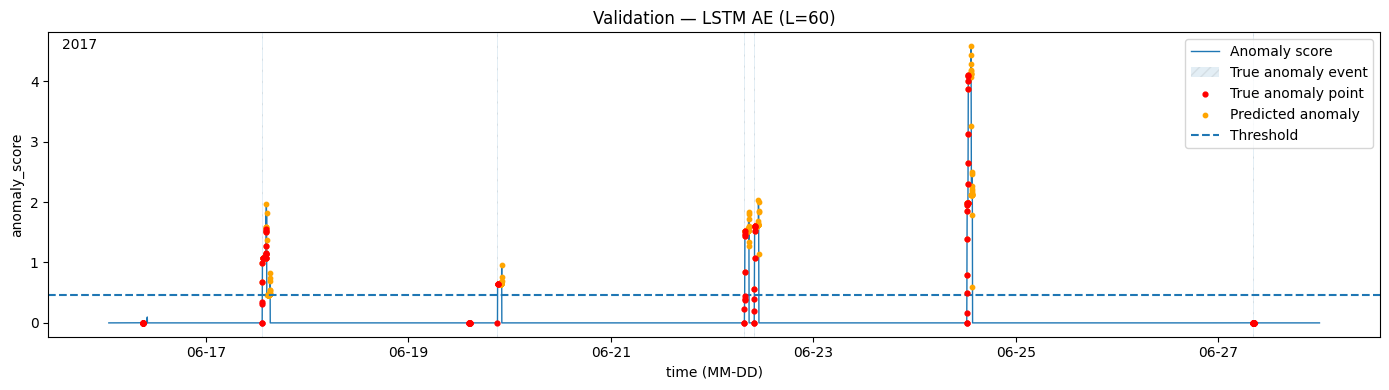

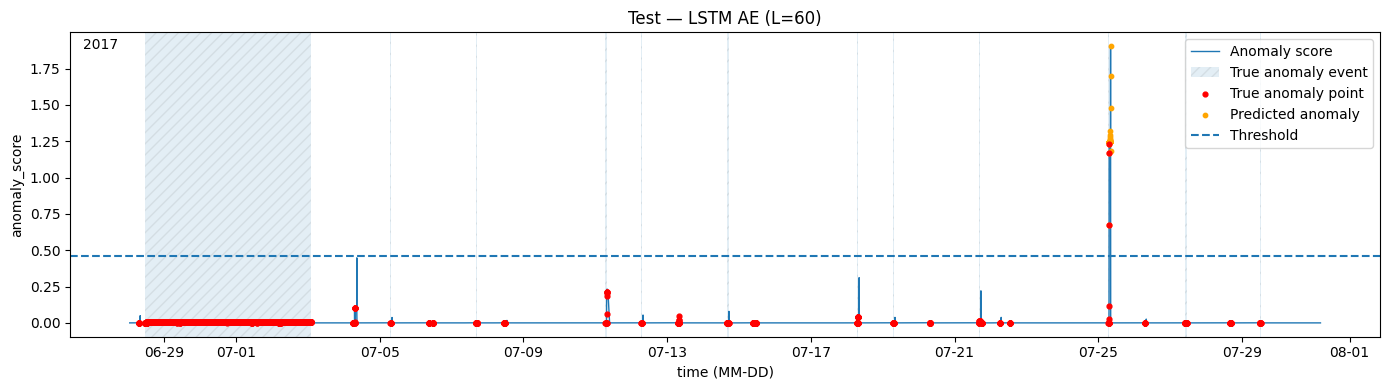

'L=120 | best_thr=0.277670'

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,0.277670,0.666667,0.454545,0.540541,0.041204,0.329114,0.073239,0.77679,0.02474,4.0
1,0.001093,0.416667,0.545455,0.472441,0.048811,0.493671,0.088838,0.77679,0.02474,1.5
2,0.001430,0.400000,0.454545,0.425532,0.050946,0.443038,0.091384,0.77679,0.02474,1.0
3,0.001357,0.312500,0.545455,0.397351,0.048452,0.455696,0.087591,0.77679,0.02474,1.5
4,0.000634,0.277778,0.545455,0.368098,0.046154,0.531646,0.084934,0.77679,0.02474,1.5


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.666667,0.454545,0.540541,4.0,0.041204,0.329114,0.073239,0.77679,0.02474


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,0.5,0.026316,0.05,3.0,0.02459,0.000428,0.000842,0.96922,0.828156


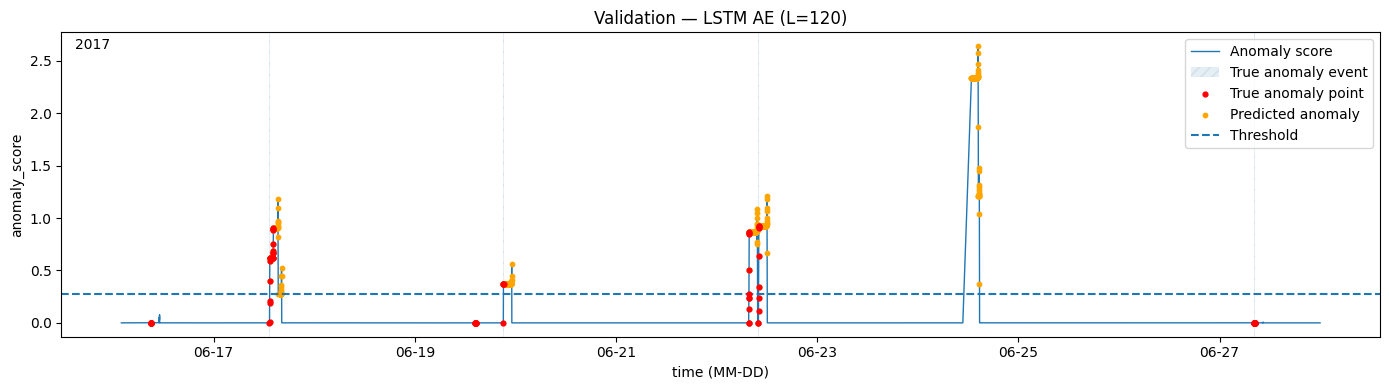

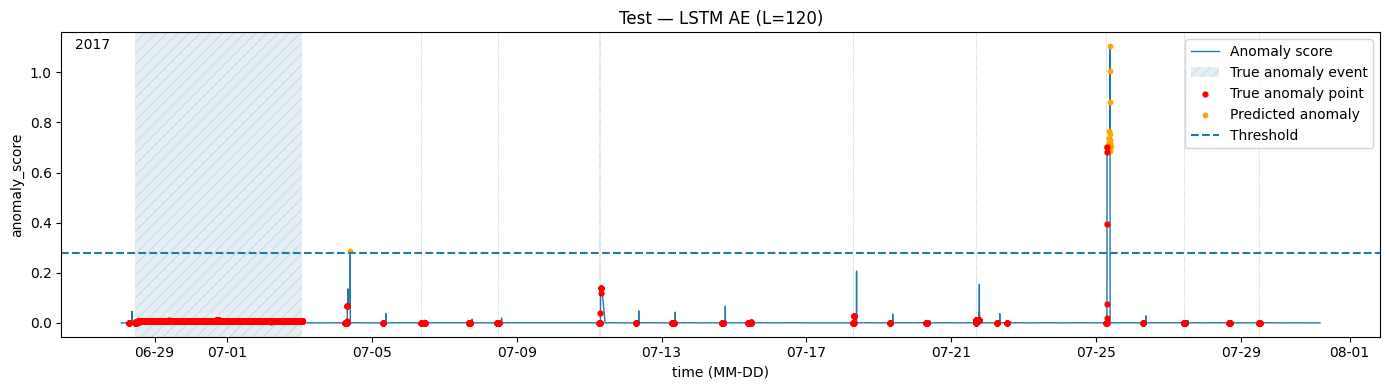

'L=360 | best_thr=0.075344'

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,0.075344,0.750000,0.454545,0.566038,0.024425,0.430380,0.046227,0.797729,0.016734,1.0
1,0.133192,0.500000,0.454545,0.476190,0.020880,0.354430,0.039437,0.797729,0.016734,3.0
2,0.000192,0.294118,0.636364,0.402299,0.021326,0.582278,0.041145,0.797729,0.016734,1.0
3,0.150650,0.400000,0.363636,0.380952,0.027439,0.341772,0.050800,0.797729,0.016734,2.0
4,0.000488,0.235294,0.545455,0.328767,0.022778,0.518987,0.043640,0.797729,0.016734,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.75,0.454545,0.566038,1.0,0.024425,0.43038,0.046227,0.797729,0.016734


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,0.333333,0.026316,0.04878,3.0,0.008242,0.000434,0.000825,0.946436,0.640064


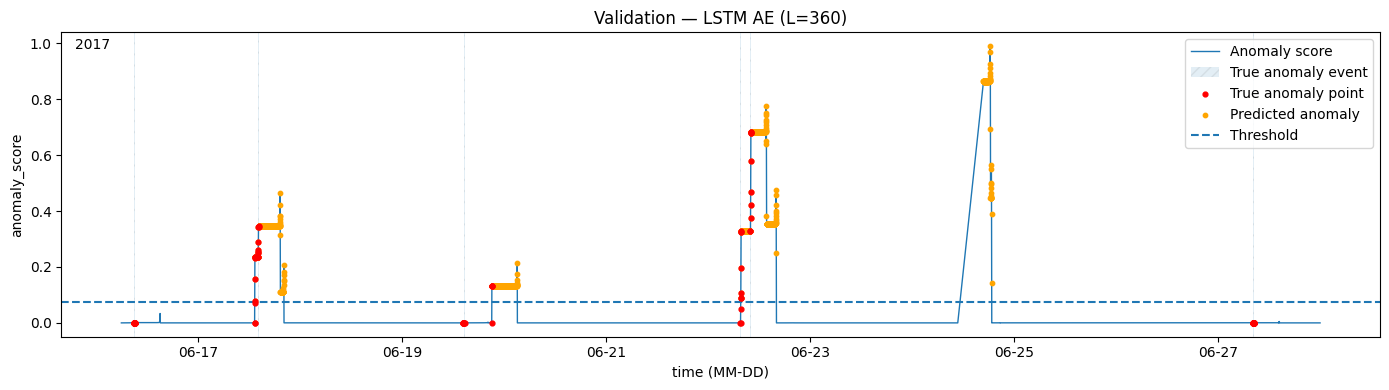

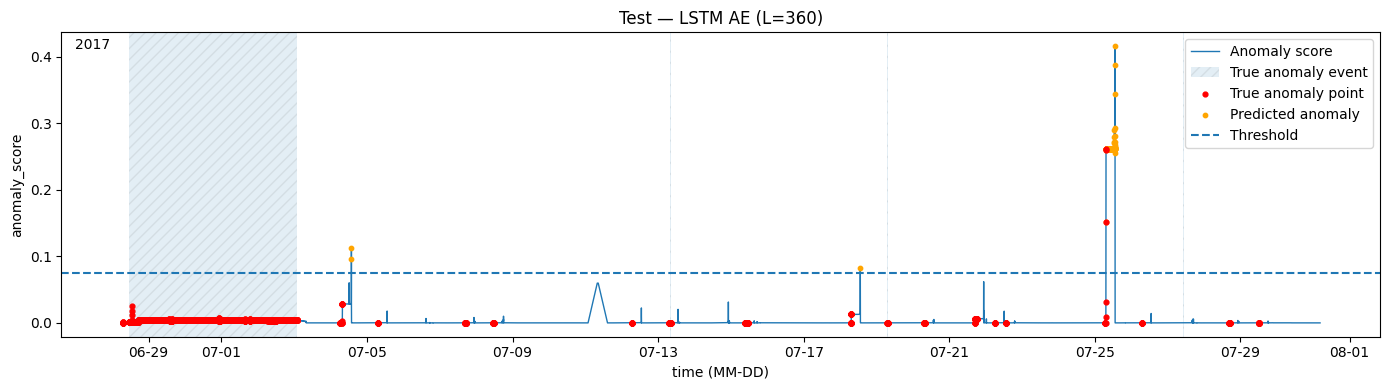

In [ ]:
# Step 8 — Formal Tier 2 sensitivity loop (per L: train, score, threshold, evaluate, save, UPSERT)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 8.1 Experiment identifiers (match Step 7)
# -----------------------------
MODEL_NAME = "lstm_ae_window_recon_mse"
TIER = 2

FEATURE_MODE = "sequence"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

SCORE_DEFINITION_KEY = "lstm_ae_recon_mse_window_end"
SCORE_DEFINITION_TEXT = "LSTM AE anomaly_score = mean reconstruction MSE per window, aligned to window end time"

THRESHOLD_STRATEGY = "val_event_f1"

# Results collector for the sensitivity summary
sensitivity_rows = []

# -----------------------------
# 8.2 Loop over candidate L values
# -----------------------------
for L in L_CANDIDATES:
    WINDOW_LENGTH_L = int(L)

    # --- Resolve windows + meta (from Step 3) ---
    X_train, meta_train = window_store[("train", WINDOW_LENGTH_L)]
    X_val,   meta_val   = window_store[("validation", WINDOW_LENGTH_L)]
    X_test,  meta_test  = window_store[("test", WINDOW_LENGTH_L)]

    # Ensure expected label + time columns exist in meta
    if "time_end" in meta_val.columns and "time" not in meta_val.columns:
        meta_val = meta_val.rename(columns={"time_end": "time"})
    if "time_end" in meta_test.columns and "time" not in meta_test.columns:
        meta_test = meta_test.rename(columns={"time_end": "time"})

    # Ensure required split labels exist (useful for saved predictions)
    if "split" not in meta_val.columns:
        meta_val["split"] = "validation"
    if "split" not in meta_test.columns:
        meta_test["split"] = "test"

    # Ensure required anomaly label column exists for harness
    if "is_anomaly" not in meta_val.columns and "is_anomaly_end" in meta_val.columns:
        meta_val["is_anomaly"] = meta_val["is_anomaly_end"].astype(int)
    if "is_anomaly" not in meta_test.columns and "is_anomaly_end" in meta_test.columns:
        meta_test["is_anomaly"] = meta_test["is_anomaly_end"].astype(int)

    # --- Deterministic run key + overwrite-only folder ---
    run_key = make_run_key(
        case_study=CASE_STUDY,
        tier=TIER,
        model_name=MODEL_NAME,
        window_length_L=WINDOW_LENGTH_L,
        feature_mode=FEATURE_MODE,
        uses_time_features=USES_TIME_FEATURES,
        contiguity_enforced=CONTIGUITY_ENFORCED,
        score_definition_key=SCORE_DEFINITION_KEY,
        threshold_strategy=THRESHOLD_STRATEGY,
    )
    run_dir = run_dir_from_key(
        run_key=run_key,
        case_study=CASE_STUDY,
        tier=TIER,
        model_slug=MODEL_NAME,
        runs_root=RUNS_ROOT,
    )
    run_id = make_run_id_timestamp()
    run_timestamp = pd.Timestamp.now().isoformat()

    # -----------------------------
    # 8.3 Train model (train only; early stopping monitors validation)
    # -----------------------------
    t0 = time.time()
    model, history_df = train_lstm_ae(X_train=X_train, X_val=X_val, config=lstm_ae_config, device="cpu")
    train_seconds = float(time.time() - t0)

    # -----------------------------
    # 8.4 Score validation/test (higher = more anomalous)
    # -----------------------------
    t1 = time.time()
    val_scores = score_lstm_ae_reconstruction_mse(model=model, X=X_val, device="cpu", batch_size=512)
    test_scores = score_lstm_ae_reconstruction_mse(model=model, X=X_test, device="cpu", batch_size=512)
    score_seconds = float(time.time() - t1)

    # -----------------------------
    # 8.5 Threshold search on validation (event-level)
    # -----------------------------
    best_thr, thr_table = select_threshold_event_f1(
        df_split=meta_val,
        scores=val_scores,
        true_events_split=true_events_val,
        n_grid=60,
    )

    # -----------------------------
    # 8.6 Evaluate at chosen threshold
    # -----------------------------
    val_metrics = evaluate_at_threshold(meta_val, val_scores, best_thr, true_events_val)
    test_metrics = evaluate_at_threshold(meta_test, test_scores, best_thr, true_events_test)

    val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
    test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

    display(f"L={WINDOW_LENGTH_L} | best_thr={best_thr:.6f}")
    display(thr_table.head(5))
    display(val_metrics_df)
    display(test_metrics_df)

    # -----------------------------
    # 8.7 Predictions + plots (shown and saved)
    # -----------------------------
    val_pred_flags = (val_scores >= best_thr).astype(int)
    test_pred_flags = (test_scores >= best_thr).astype(int)

    fig_val = plot_score_timeline(
        df_split=meta_val,
        scores=val_scores,
        threshold=float(best_thr),
        title=f"Validation — LSTM AE (L={WINDOW_LENGTH_L})",
        true_events_split=true_events_val,
        pred_is_anomaly=val_pred_flags,
    )
    plt.show()
    fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
    plt.close(fig_val)

    fig_test = plot_score_timeline(
        df_split=meta_test,
        scores=test_scores,
        threshold=float(best_thr),
        title=f"Test — LSTM AE (L={WINDOW_LENGTH_L})",
        true_events_split=true_events_test,
        pred_is_anomaly=test_pred_flags,
    )
    plt.show()
    fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
    plt.close(fig_test)

    # -----------------------------
    # 8.8 Save per-run artefacts
    # -----------------------------
    config = {
        "run_key": run_key,
        "run_id": run_id,
        "run_timestamp": run_timestamp,
        "case_study": CASE_STUDY,
        "tier": TIER,
        "model_name": MODEL_NAME,
        "random_seed": int(lstm_ae_config["seed"]),

        "window_length_L": WINDOW_LENGTH_L,
        "feature_mode": FEATURE_MODE,
        "uses_time_features": USES_TIME_FEATURES,
        "contiguity_enforced": CONTIGUITY_ENFORCED,

        "lstm_ae_config": dict(lstm_ae_config),
        "score_definition": SCORE_DEFINITION_TEXT,
        "threshold_strategy": THRESHOLD_STRATEGY,
    }
    save_json(config, run_dir / "config.json")

    save_json(
        {
            "threshold_strategy": THRESHOLD_STRATEGY,
            "threshold_value": float(best_thr),
            "validation_best_row": thr_table.iloc[0].to_dict(),
        },
        run_dir / "threshold.json",
    )

    val_pred = pd.DataFrame({
        "time": meta_val["time"],
        "anomaly_score": val_scores,
        "pred_is_anomaly": val_pred_flags,
        "is_anomaly": meta_val["is_anomaly"].astype(int),
        "split": "validation",
        "case_study": CASE_STUDY,
    })
    test_pred = pd.DataFrame({
        "time": meta_test["time"],
        "anomaly_score": test_scores,
        "pred_is_anomaly": test_pred_flags,
        "is_anomaly": meta_test["is_anomaly"].astype(int),
        "split": "test",
        "case_study": CASE_STUDY,
    })

    save_df(val_pred, run_dir / "val_predictions.csv")
    save_df(test_pred, run_dir / "test_predictions.csv")
    save_df(val_metrics_df, run_dir / "val_metrics.csv")
    save_df(test_metrics_df, run_dir / "test_metrics.csv")
    save_df(thr_table, run_dir / "val_threshold_grid.csv")
    save_df(history_df, run_dir / "train_history.csv")

    # -----------------------------
    # 8.9 Log performance-only results (UPSERT by run_key)
    # -----------------------------
    notes = auto_notes(
        val_event_precision=float(val_metrics["event_precision"]),
        val_event_recall=float(val_metrics["event_recall"]),
        val_event_f1=float(val_metrics["event_f1"]),
        test_event_precision=float(test_metrics["event_precision"]),
        test_event_recall=float(test_metrics["event_recall"]),
        test_event_f1=float(test_metrics["event_f1"]),
        test_pr_auc=float(test_metrics["pr_auc"]),
        threshold_strategy=THRESHOLD_STRATEGY,
    )

    row = normalise_perf_row({
        "run_key": run_key,
        "run_id": run_id,
        "run_timestamp": run_timestamp,

        "case_study": CASE_STUDY,
        "tier": TIER,
        "model_name": MODEL_NAME,

        "window_length_L": WINDOW_LENGTH_L,
        "feature_mode": FEATURE_MODE,
        "uses_time_features": USES_TIME_FEATURES,
        "contiguity_enforced": CONTIGUITY_ENFORCED,
        "score_definition": SCORE_DEFINITION_TEXT,

        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),

        "val_event_precision": float(val_metrics["event_precision"]),
        "val_event_recall": float(val_metrics["event_recall"]),
        "val_event_f1": float(val_metrics["event_f1"]),
        "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

        "test_event_precision": float(test_metrics["event_precision"]),
        "test_event_recall": float(test_metrics["event_recall"]),
        "test_event_f1": float(test_metrics["event_f1"]),
        "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

        "test_point_precision": float(test_metrics["point_precision"]),
        "test_point_recall": float(test_metrics["point_recall"]),
        "test_point_f1": float(test_metrics["point_f1"]),
        "test_auroc": float(test_metrics["auroc"]),
        "test_pr_auc": float(test_metrics["pr_auc"]),

        "train_seconds": float(train_seconds),
        "score_seconds": float(score_seconds),

        "notes": notes,
    })
    upsert_all_results_row(row)
    notes

    # Collect sensitivity summary
    sensitivity_rows.append(
        {
            "L_minutes": WINDOW_LENGTH_L,
            "val_event_precision": float(val_metrics["event_precision"]),
            "val_event_recall": float(val_metrics["event_recall"]),
            "val_event_f1": float(val_metrics["event_f1"]),
            "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),
            "test_event_precision": float(test_metrics["event_precision"]),
            "test_event_recall": float(test_metrics["event_recall"]),
            "test_event_f1": float(test_metrics["event_f1"]),
            "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),
            "test_pr_auc": float(test_metrics["pr_auc"]),
            "test_auroc": float(test_metrics["auroc"]),
            "best_threshold": float(best_thr),
            "train_seconds": float(train_seconds),
            "score_seconds": float(score_seconds),
            "run_key": run_key,
        }
    )

# -----------------------------
# 8.10 Sensitivity summary table
# -----------------------------
sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("L_minutes").reset_index(drop=True)
display(sensitivity_df)
